# Raw tracking â†’ yardage distributions

## Hackathon question
Can player geometry at the ball snap predict pre-penalty yardage without formation, coverage, PFF, personnel, or post-snap tracking labels?

This notebook is the reproducible entry point for the raw-tracking model. It uses `yardage_distribution.py` for feature engineering and XGBoost quantile regression, then displays the held-out metrics and a smooth probability distribution for a representative play.

## Method

- **Target:** `prePenaltyPlayResult`
- **Inputs:** ball-snap locations, speed, acceleration, direction, cross-team distances, and shared controls (`down`, `yardsToGo`, `absoluteYardlineNumber`)
- **Validation:** games are held out as whole groups, so plays from a game never occur in both train and test
- **Distribution:** XGBoost predicts the 10th, 25th, 50th, 75th, and 90th yardage quantiles; these are interpolated into Monte Carlo draws per play

The formation/coverage-label benchmark should use the same target, held-out game split, and shared controls.

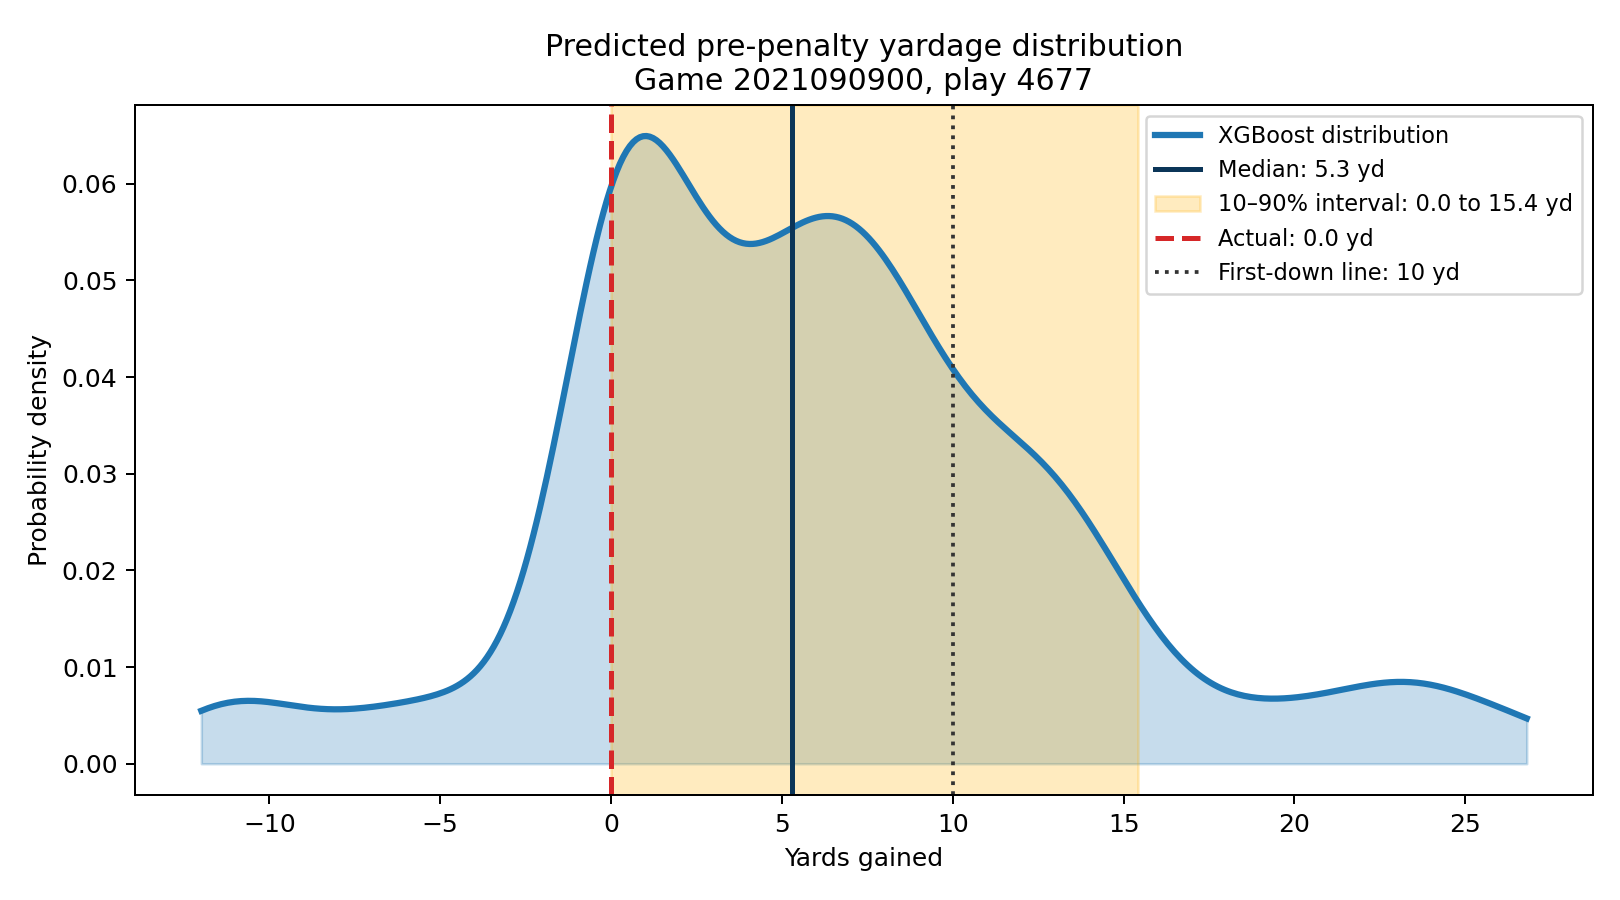

In [ ]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Image, display

PROJECT_DIR = Path.cwd()
if not (PROJECT_DIR / 'yardage_distribution.py').exists():
    raise FileNotFoundError('Open this notebook from the nfl hackathon project folder.')

DATA_DIR = PROJECT_DIR / 'nfl-regional-data' / 'data'
RESULTS_DIR = PROJECT_DIR / 'results'
assert DATA_DIR.exists(), 'Download the regional-event data before running the model.'
print(f'Data: {DATA_DIR}')
print(f'Results: {RESULTS_DIR}')

## Run the full raw-tracking model

This takes a few minutes for all 122 games. It overwrites the contents of `results/` with the latest held-out predictions, metrics, feature importance, and smooth distribution figure.

In [ ]:
import subprocess

subprocess.run(
    [sys.executable, 'yardage_distribution.py', '--all-games'],
    cwd=PROJECT_DIR,
    check=True,
)

## Held-out performance

Interpret MAE as average absolute error in yards. `p10_p90_coverage` should be close to 0.80: it tests whether the nominal 80% predictive interval is calibrated.

In [ ]:
metrics = pd.read_csv(RESULTS_DIR / 'metrics.csv')
display(metrics.T.rename(columns={0: 'value'}))

Metric,Held-out result
Games / plays,"122 / 8,532"
MAE,7.16 yards
RMSE,11.21 yards
R²,-0.086
10–90% interval coverage,79.6%


## Example play: predicted yardage distribution

The smooth curve is the predicted distribution. The shaded band is the 10â€“90% interval, the dark line is the median, and the red dashed line is the actual pre-penalty yardage.

In [ ]:
display(Image(filename=RESULTS_DIR / 'heldout_yardage_distribution_example.png'))

## Next comparison

Run the formation/coverage model on the identical held-out games. Present a table with MAE, RMSE, RÂ², and interval coverage for both approaches. The useful conclusion is comparative: whether raw geometry adds signal beyond charted labelsâ€”not whether either model perfectly predicts a noisy final-play outcome.